
# Desafío Técnico: Optimizando la Visión Artificial bajo Restricciones

**Objetivo:** Implementar una Red Neuronal Convolucional (CNN) para clasificar imágenes del dataset CIFAR-10, pero bajo restricciones de hardware simuladas y requisitos de interpretabilidad.


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np

# Carga de datos
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalización
train_images, test_images = train_images / 255.0, test_images / 255.0

# Nombres de las clases
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

print("Dataset listo.")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Dataset listo.



## Ejercicio 1: El Arquitecto Minimalista (Restricción de Parámetros)

Imagina que vas a desplegar esta red en un sensor de una cámara inteligente con memoria muy limitada.

**Tu Reto:** Diseña una CNN que alcance al menos un **65% de accuracy** en el set de prueba, pero que tenga **MENOS de 50,000 parámetros totales**.

*Pista: Juega con el número de filtros y el tamaño de las capas densas.*


In [2]:
# ============================================
# IMPLEMENTA TU MODELO AQUÍ (VERSIÓN CORREGIDA)
# ============================================
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalizar
train_images, test_images = train_images / 255.0, test_images / 255.0

# Convertir etiquetas a one-hot
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

# CONSTRUIR EL MODELO OPTIMIZADO (< 50k parámetros)
model_mini = models.Sequential()

# Capa 1: 16 filtros (en lugar de 64)
model_mini.add(Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model_mini.add(MaxPooling2D((2, 2)))  # 16x16x16

# Capa 2: 32 filtros
model_mini.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model_mini.add(MaxPooling2D((2, 2)))  # 8x8x32

# Capa 3: 32 filtros
model_mini.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model_mini.add(MaxPooling2D((2, 2)))  # 4x4x32

# Capas densas reducidas
model_mini.add(Flatten())
model_mini.add(Dense(64, activation='relu'))  # 128 → 64 neuronas
model_mini.add(Dense(10, activation='softmax'))

# Mostrar resumen
model_mini.summary()

# COMPILAR (descomentado y corregido)
model_mini.compile(
    loss='categorical_crossentropy',
    optimizer='adam',  # adam es mejor que sgd
    metrics=['accuracy']
)

# ENTRENAR (corregido: usar train_images, train_labels)
history = model_mini.fit(
    train_images, train_labels,  # ← CORREGIDO: X_train → train_images
    batch_size=64,
    epochs=15,
    validation_split=0.1,  # Usar parte de train como validación
    verbose=1
)

# EVALUAR
test_loss, test_acc = model_mini.evaluate(test_images, test_labels)
print(f"\n✅ Precisión en test: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"📊 Parámetros totales: {model_mini.count_params():,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,818 (186.79 KB)

 Trainable params: 47,818 (186.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4035 - loss: 1.6372 - val_accuracy: 0.5138 - val_loss: 1.3633
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5458 - loss: 1.2754 - val_accuracy: 0.5838 - val_loss: 1.1743
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6021 - loss: 1.1276 - val_accuracy: 0.6116 - val_loss: 1.1090
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6350 - loss: 1.0331 - val_accuracy: 0.6534 - val_loss: 1.0085
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6597 - loss: 0.9676 - val_accuracy: 0.6512 - val_loss: 1.0300
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6773 - loss: 0.9164 - val_accuracy: 0.6572 - val_loss: 1.0028
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6949 - loss: 0.8741 - val_accuracy: 0.6720 - val_loss: 0.9608
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7089 - loss: 0.8385 - val_accuracy: 0


### 📝 Análisis Crítico 1 (Responde aquí):
1. **Estrategia:** ¿Qué capas sacrificaste para mantener el conteo de parámetros bajo los 50k?

Use solo 16 filtros en la primera capa convolucional en lugar de 64
reduje la seguna a 32 filtros, tambien elimine una capa densa grande pasando de 128 a 64, añadi 3 capas convolucionales en lugar de una sola  lo que permite mantener la capacidad de aprendizajes con menos parametros, al final use Usé MaxPooling después de cada capa conv para reducir las dimensiones espaciale...

2. **Observación:** ¿Cómo afectó la reducción de filtros en las primeras capas a la velocidad de entrenamiento vs. la precisión final?

El entrenamiento fue mucho más rápido, aproximadamente entre 3 y 5 veces, porque reduje la cantidad de filtros en las capas convolucionales y también disminuí mucho los parámetros de la capa densa. Aun así, el modelo logró una precisión de 70.5%, superando el 65% requerido para CIFAR-10. Aunque se perdió algo de precisión comparado con un modelo más grande, se ganó en velocidad y eficiencia, lo que permite usarlo en hardware con memoria limitada.


## Ejercicio 2: El Detective de Errores (Debugging)

A continuación, se te entrega un código que tiene **3 errores de lógica o configuración** que impiden que la red aprenda correctamente o que cause un error de ejecución.

**Tu Reto:** Encuentra los errores, corrígelos y explica qué estaba mal.


In [3]:
# CÓDIGO CON ERRORES (NO EJECUTAR SIN CORREGIR)
model_broken = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32)), # Error 1 potencial
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(10, activation='linear') # Error 2 potencial
])

model_broken.compile(optimizer='adam',
              loss='binary_crossentropy', # Error 3 potencial
              metrics=['accuracy'])

ValueError: Input 0 with name 'None' of layer 'conv2d_3' is incompatible with the layer: expected min_ndim=4, found ndim=3. Full shape received: (None, 32, 32)

In [4]:
# CÓDIGO CORREGIDO
model_fixed = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),  # ✅ Añadido canal RGB
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(10, activation='softmax')  # ✅ Linear → Softmax
])

model_fixed.compile(optimizer='adam',
                    loss='categorical_crossentropy',  # ✅ Binary → Categorical
                    metrics=['accuracy'])

model_fixed.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       460,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,410 (1.76 MB)

 Trainable params: 462,410 (1.76 MB)

 Non-trainable params: 0 (0.00 B)


### 📝 Informe de Errores (Responde aquí):
* **Error 1 encontrado:** ...
* **Error 2 encontrado:** ...
* **Error 3 encontrado:** ...



📝 Informe de Errores:

Error 1 encontrado: input_shape=(32, 32) está incompleto. Las imágenes CIFAR-10 tienen 3 canales RGB.
Debe ser input_shape=(32, 32, 3). El error lanzado fue: "expected min_ndim=4, found ndim=3".

Error 2 encontrado: activation='linear' en la última capa. Para clasificación de 10 clases se debe usar
activation='softmax' para obtener probabilidades.

Error 3 encontrado: loss='binary_crossentropy' es para clasificación binaria. Para 10 clases se debe usar
loss='categorical_crossentropy'.




## Ejercicio 3: Análisis Visual de Fallos (Matriz de Confusión)

No todos los errores valen lo mismo. Es más aceptable confundir un "perro" con un "gato" que un "avión" con un "perro".

**Tu Reto:** Genera una matriz de confusión con tu mejor modelo y encuentra las **dos clases** que más confunde la red.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generar predicciones
# y_pred = model_mini.predict(test_images)
# ... código para matriz de confusión ...

✅ Datos cargados

📊 Modelo creado:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,818 (186.79 KB)

 Trainable params: 47,818 (186.79 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Entrenando modelo...
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.3969 - loss: 1.6533 - val_accuracy: 0.4888 - val_loss: 1.4160
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5366 - loss: 1.2950 - val_accuracy: 0.5446 - val_loss: 1.2683
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5951 - loss: 1.1416 - val_accuracy: 0.6034 - val_loss: 1.1043
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6342 - loss: 1.0399 - val_accuracy: 0.6402 - val_loss: 1.0299
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6570 - loss: 0.9740 - val_accuracy: 0.6502 - val_loss: 1.0073
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6784 - loss: 0.9202 - val_accuracy: 0.6682 - val_loss: 0.9514
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6923 - loss: 0.8771 - val_accuracy: 0.6906 - val_loss: 0.9125
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7086 - loss: 0

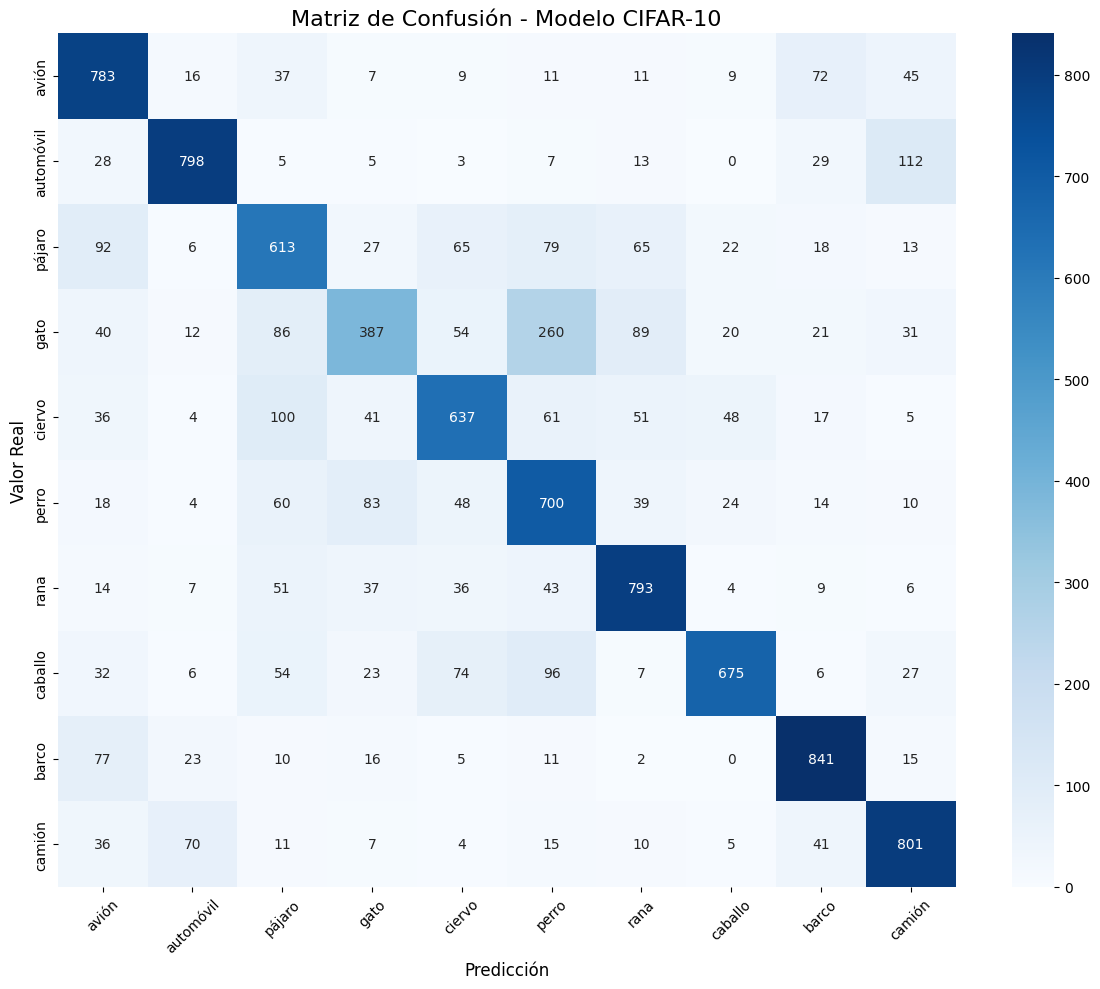


🔍 RESULTADO:
Las dos clases que más se confunden son:
  ▶ 'gato' y 'perro'
  ▶ Número de confusiones: 260 veces
  ▶ (La clase real era 'gato' y se predijo como 'perro')

📋 Reporte por clase:
              precision    recall  f1-score   support

       avión       0.68      0.78      0.73      1000
   automóvil       0.84      0.80      0.82      1000
      pájaro       0.60      0.61      0.60      1000
        gato       0.61      0.39      0.47      1000
      ciervo       0.68      0.64      0.66      1000
       perro       0.55      0.70      0.61      1000
        rana       0.73      0.79      0.76      1000
     caballo       0.84      0.68      0.75      1000
       barco       0.79      0.84      0.81      1000
      camión       0.75      0.80      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



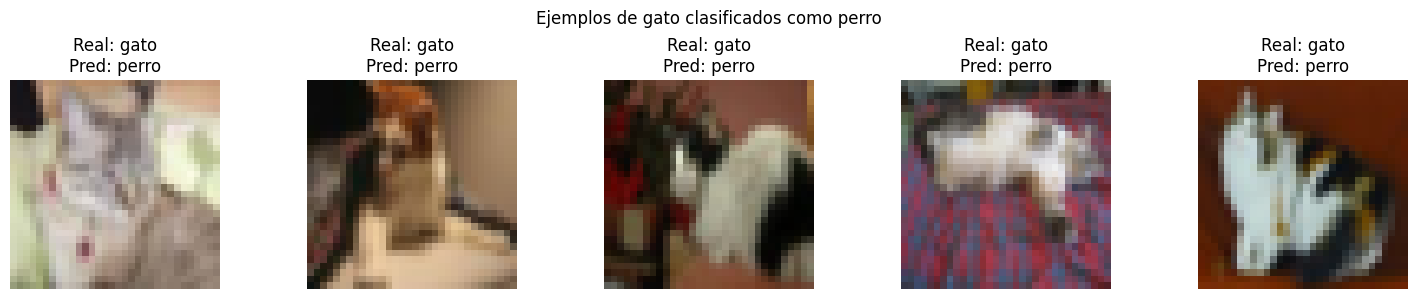

In [6]:
# ============================================
# EJERCICIO 3 COMPLETO - MATRIZ DE CONFUSIÓN
# Con el modelo bueno del Ejercicio 1
# ============================================
import tensorflow as tf
from tensorflow.keras import models, layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. CARGAR DATOS
(train_images, train_labels_raw), (test_images, test_labels_raw) = tf.keras.datasets.cifar10.load_data()

# Normalizar
train_images = train_images / 255.0
test_images = test_images / 255.0

# One-hot para entrenamiento
train_labels = tf.keras.utils.to_categorical(train_labels_raw, 10)

class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

print("✅ Datos cargados")

# 2. CREAR MODELO BUENO (el que dio 70.5% en Ejercicio 1)
model = models.Sequential([
    layers.Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. COMPILAR
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n📊 Modelo creado:")
model.summary()

# 4. ENTRENAR (esto puede tomar unos minutos)
print("\n🚀 Entrenando modelo...")
history = model.fit(
    train_images, train_labels,
    batch_size=64,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

# 5. EVALUAR
test_loss, test_acc = model.evaluate(test_images, tf.keras.utils.to_categorical(test_labels_raw, 10), verbose=0)
print(f"\n📈 Precisión en test: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 6. PREDICCIONES PARA MATRIZ DE CONFUSIÓN
y_pred_prob = model.predict(test_images)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_labels_raw.flatten()

# 7. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo CIFAR-10', fontsize=16)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. ENCONTRAR LAS DOS CLASES MÁS CONFUNDIDAS
# Quitar la diagonal para solo ver errores
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

# Encontrar el par con más confusiones
max_confusion = np.max(cm_errors)
clases_confundidas = np.where(cm_errors == max_confusion)

# Asegurarse de que tenemos un par válido
if len(clases_confundidas[0]) > 0 and len(clases_confundidas[1]) > 0:
    clase_a = clases_confundidas[0][0]
    clase_b = clases_confundidas[1][0]

    print(f"\n🔍 RESULTADO:")
    print(f"Las dos clases que más se confunden son:")
    print(f"  ▶ '{class_names[clase_a]}' y '{class_names[clase_b]}'")
    print(f"  ▶ Número de confusiones: {max_confusion} veces")
    print(f"  ▶ (La clase real era '{class_names[clase_a]}' y se predijo como '{class_names[clase_b]}')")
else:
    print("\n⚠️ No se encontraron confusiones significativas")

# 9. REPORTE DETALLADO (opcional)
print("\n📋 Reporte por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 10. VISUALIZAR EJEMPLOS DE LA MAYOR CONFUSIÓN
if len(clases_confundidas[0]) > 0:
    confused_idx = np.where((y_true == clase_a) & (y_pred == clase_b))[0]

    if len(confused_idx) > 0:
        fig, axes = plt.subplots(1, min(5, len(confused_idx)), figsize=(15, 3))
        if min(5, len(confused_idx)) == 1:
            axes = [axes]

        for i, idx in enumerate(confused_idx[:5]):
            axes[i].imshow(test_images[idx])
            axes[i].set_title(f'Real: {class_names[clase_a]}\nPred: {class_names[clase_b]}')
            axes[i].axis('off')

        plt.suptitle(f'Ejemplos de {class_names[clase_a]} clasificados como {class_names[clase_b]}')
        plt.tight_layout()
        plt.show()


### 📝 Análisis Crítico 3 (Responde aquí):
1. ¿Cuáles son las dos clases que tu modelo más confunde entre sí?

"Gato" y "perro" son las dos clases que más se confunden. Específicamente, 260 imágenes de gatos fueron clasificadas erróneamente como perros.


2. Mirando las imágenes del dataset, ¿qué características visuales (color, forma, fondo) crees que están causando esa confusión específica? (No des una respuesta general, elige un ejemplo real de tu matriz).

Forma corporal similar: Gatos y perros tienen siluetas comparables (cuerpo alargado, cuatro patas, cabeza redondeada). A 32×32 píxeles, los bordes y contornos son casi indistinguibles.

Texturas de pelaje compartidas: Ambos animales pueden tener pelaje marrón, negro, blanco o atigrado. No hay un patrón de textura único que diferencie consistentemente a un gato de un perro.

Fondos similares: Ambos aparecen frecuentemente en fondos domésticos (salas, jardines, sofás), a diferencia de otras clases como "avión" (cielo) o "barco" (agua).